In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('../data/features/decision_tree_features.csv')
df

,season,date,event,weight_class,wrestler,wrestler_id,wrestler_school,opponent,opponent_id,opponent_school,...,opponent_avg_points_scored_last_5,scoring_advantage_last_5,opponent_avg_points_allowed_last_5,defensive_advantage_last_5,opponent_days_since_last_match,rest_differential,h2h_key,h2h_matches,h2h_wins,h2h_win_rate
0,2013/2014,2013-11-22,Baker (Kan) - Iowa Dual,165,Nick Moore,11454,Iowa,Jakob Price,37118,Baker,...,NaN,NaN,NaN,NaN,0.0,0.0,"(11454, 37118)",0,0,0.5
1,2013/2014,2013-11-22,Iowa Central Community College - Iowa Dual,165,Nick Moore,11454,Iowa,Corbin Farrell,11456,Iowa Central Community College,...,5.00,-5.000000,2.00,-2.000000,19.0,-19.0,"(11454, 11456)",0,0,0.5
2,2013/2014,2013-12-01,Iowa - Iowa State Dual,165,Nick Moore,11454,Iowa,Michael Moreno,11457,Iowa State,...,12.75,-12.750000,3.75,-3.750000,7.0,2.0,"(11454, 11457)",0,0,0.5
3,2013/2014,2013-12-05,Iowa - Edinboro Dual,165,Nick Moore,11454,Iowa,Zach Towers,11458,Edinboro,...,NaN,NaN,NaN,NaN,0.0,4.0,"(11454, 11458)",0,0,0.5
4,2013/2014,2013-12-12,Iowa - Buffalo Dual,165,Nick Moore,11454,Iowa,Wally Maziarz,11459,Buffalo,...,2.75,0.750000,7.00,-5.750000,4.0,3.0,"(11454, 11459)",0,0,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
506467,2024/2025,2025-03-02,Zingo Nationals,197,Tommy Renna,101228,Unattached,Kevin Taylor,93979,Sacred Heart,...,1.60,-1.600000,9.40,0.600000,14.0,-14.0,"(93979, 101228)",0,0,0.5
506468,2022/2023,2022-11-13,Jonathan Kaloust Bearcat Open,197,Jude Correa,101285,High School,Lucas Cochran,71705,Penn State,...,10.60,NaN,1.80,NaN,288.0,-288.0,"(71705, 101285)",0,0,0.5
506469,2022/2023,2022-11-13,Jonathan Kaloust Bearcat Open,197,Jude Correa,101285,High School,Levko Higgins,50870,Penn State,...,3.80,-2.800000,4.80,0.200000,280.0,-280.0,"(50870, 101285)",0,0,0.5
506470,2022/2023,2022-11-13,Jonathan Kaloust Bearcat Open,197,Jude Correa,101285,High School,Franklin Cruz,72182,Northern Colorado,...,0.00,0.500000,0.00,2.500000,0.0,0.0,"(72182, 101285)",0,0,0.5


In [4]:
def temporal_train_test_split(X, y, test_size=0.2, split_date=None):
    """Split data based on time to avoid data leakage"""
    
    if split_date is None:
        # Calculate split date based on test_size
        sorted_dates = X['date'].sort_values()
        split_idx = int(len(sorted_dates) * (1 - test_size))
        split_date = sorted_dates.iloc[split_idx]
    
    # Create temporal split
    train_mask = X['date'] < split_date
    test_mask = X['date'] >= split_date
    
    X_train = X[train_mask]
    X_test = X[test_mask]
    y_train = y[train_mask]
    y_test = y[test_mask]
    
    print(f"Split date: {split_date}")
    print(f"Train set: {len(X_train)} matches ({X_train['date'].min()} to {X_train['date'].max()})")
    print(f"Test set: {len(X_test)} matches ({X_test['date'].min()} to {X_test['date'].max()})")
    
    return X_train.drop(columns='date'), X_test.drop(columns='date'), y_train, y_test

In [5]:
def prepare_data_for_modeling(df):
    exclude_cols = [
        'duration_seconds', 'point_differential',
        'wrestler_score', 'opponent_score', 
        'result', 'result_type', 'is_overtime', 
        'bonus_win', 'close_match', 'h2h_key',
        'season', 'year', 'wrestler', 'opponent', 
        'event', 'wrestler_school', 'opponent_school',
        'close_match_win'
    ]

    priority_features = [col for col in df.columns if col not in exclude_cols + ['is_win', 'date']]
    
    # Remove rows with NaN values in priority features
    df_clean = df.dropna(subset=priority_features + ['is_win'])
    print(f"Data cleaned: {len(df_clean)} matches remaining after removing NaNs")
    
    # Separate features and target, keep date column
    X = df_clean[priority_features + ['date']].copy()
    y = df_clean['is_win'].copy()

    X_train, X_test, y_train, y_test = temporal_train_test_split(X, y)
    
    return X_train, X_test, y_train, y_test, priority_features

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

In [7]:
def get_feature_importance(model, feature_names):
    """Get feature importance dataframe"""
    feature_importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    return feature_importance_df

In [8]:
def evaluate_rf_model(model, X_train, X_test, y_train, y_test, model_name="Random Forest"):
    """Comprehensive model evaluation"""
    print("\n" + "="*50)
    print(f"{model_name.upper()} EVALUATION")
    print("="*50)
    
    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    auc_score = roc_auc_score(y_test, y_pred_proba)
    
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy:  {test_acc:.4f}")
    print(f"ROC AUC Score:  {auc_score:.4f}")
    print(f"Overfitting:    {train_acc - test_acc:.4f}")
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Loss', 'Win']))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"\nConfusion Matrix:")
    print(f"              Predicted")
    print(f"              Loss  Win")
    print(f"Actual Loss   {cm[0,0]:4d} {cm[0,1]:4d}")
    print(f"       Win    {cm[1,0]:4d} {cm[1,1]:4d}")
    
    return {
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'auc_score': auc_score,
        'predictions': y_pred,
        'probabilities': y_pred_proba,
        'confusion_matrix': cm
    }

In [9]:
def train_base_model(X_train, y_train, n_estimators=500):
    
    print(f"\nTraining baseline Random Forest with {n_estimators} trees...")
    
    # Train model
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42
    )

    model.fit(X_train, y_train)
    
    print(f"Baseline model trained successfully")
    return model

In [10]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.feature_selection import SelectFromModel
import time

In [11]:
import matplotlib.pyplot as plt

def plot_cross_val(splitter_func,
                   df: pd.DataFrame,
                   title_text: str) -> None:
    """Function to plot the cross validation of various
    sklearn splitter objects."""

    n_samples = df.shape[0]
    train_window_size = 80000
    test_window_size = 20000
    n_splits = (n_samples - train_window_size - test_window_size) // (test_window_size) + 1
    
    split = 1
    plot_data = []
    for train_index, valid_index in splitter_func(n_splits=n_splits,
                                                max_train_size=train_window_size,
                                                test_size=test_window_size).split(df):
        plot_data.append([train_index, 'Train', f'{split}'])
        plot_data.append([valid_index, 'Test', f'{split}'])
        split += 1

    plot_df = pd.DataFrame(plot_data,
                           columns=['Index', 'Dataset', 'Split'])\
                           .explode('Index')
    plot_df['Split'] = pd.to_numeric(plot_df['Split'])
    
    # Create matplotlib figure
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Plot data for each split
    train_plotted = False
    test_plotted = False
    
    for _, group in plot_df.groupby('Split'):
        train_data = group[group['Dataset'] == 'Train']
        test_data = group[group['Dataset'] == 'Test']
        
        # Plot train data
        ax.scatter(train_data['Index'], train_data['Split'], 
                  color='blue', s=50, alpha=0.7,
                  label='Train' if not train_plotted else "")
        train_plotted = True
        
        # Plot test data  
        ax.scatter(test_data['Index'], test_data['Split'],
                  color='goldenrod', s=50, alpha=0.7,
                  label='Test' if not test_plotted else "")
        test_plotted = True
    
    # Customize the plot
    ax.set_xlabel('Index', fontsize=16)
    ax.set_ylabel('Split', fontsize=16)
    ax.set_title(title_text, fontsize=18, pad=20)
    ax.legend(fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=14)
    
    # Set background color to white
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    
    plt.tight_layout()
    plt.show()

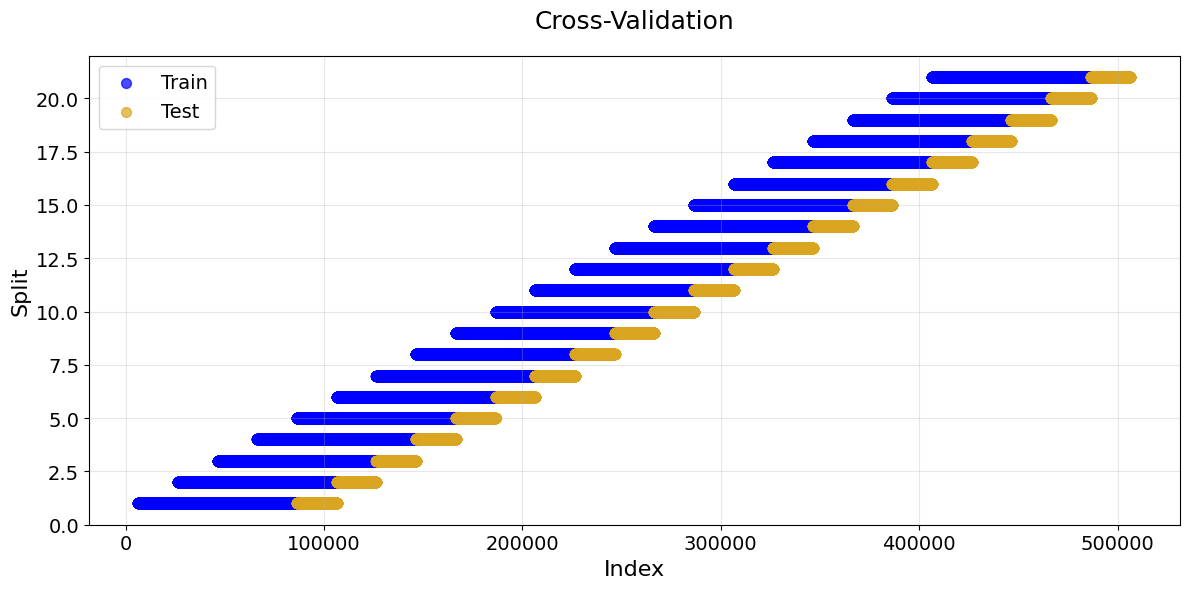

In [12]:
plot_cross_val(splitter_func=TimeSeriesSplit,
            df=df,
            title_text='Cross-Validation')

In [22]:
def tune_hyperparameters(X_train, y_train, n_iter=50, train_window_size=80000, test_window_size=20000):
    """Perform hyperparameter tuning using blocked cross-validation"""
    print(f"\nPerforming hyperparameter tuning...")
    
    param_distributions = {
        'n_estimators': [100, 200, 300, 500, 750],
        'max_depth': [None, 10, 15, 25],
        'min_samples_split': [2, 5, 10, 20],
        'min_samples_leaf': [2, 5, 10],
        'max_features': ['sqrt', 'log2', 0.3, 0.5],
        'bootstrap': [True],
        'class_weight': ['balanced', None, {0: 1, 1: 1.1}, {0: 1, 1: 1.2}]
    }

    n_samples = X_train.shape[0]
    n_splits = (n_samples - train_window_size - test_window_size) // (test_window_size) + 1

    tscv = TimeSeriesSplit(
        n_splits=n_splits,
        max_train_size=train_window_size,
        test_size=test_window_size
        )

    rf_tuning = RandomForestClassifier(random_state=42, n_jobs=-1)
    
    random_search = RandomizedSearchCV(
        rf_tuning,
        param_distributions,
        n_iter=n_iter,
        cv=tscv,
        scoring='roc_auc',
        random_state=42,
        n_jobs=-1,
        verbose=3
    )
    
    start_time = time.time()
    random_search.fit(X_train, y_train)
    print(f"Completed in {time.time() - start_time:.2f} seconds")
    
    print(f"Best parameters: {random_search.best_params_}")
    print(f"Best CV score: {random_search.best_score_:.4f}")
    
    return random_search.best_estimator_, random_search.best_params_

In [14]:
def select_features(model, X_train, X_test, y_train, y_test, feature_names, threshold='median'):
    """Perform feature selection based on importance"""
    print(f"\nPerforming feature selection (threshold: {threshold})...")
    
    # Create feature selector
    selector = SelectFromModel(model, threshold=threshold, prefit=True)
    
    # Transform data
    X_train_selected = selector.transform(X_train)
    X_test_selected = selector.transform(X_test)
    
    # Get selected feature names
    selected_mask = selector.get_support()
    selected_features = [f for f, selected in zip(feature_names, selected_mask) if selected]
    
    print(f"Selected {len(selected_features)} features out of {len(feature_names)}")
    print(f"Top selected features: {selected_features[:10]}")
    
    # Retrain model with selected features
    print("Retraining model with selected features...")
    rf_selected = RandomForestClassifier(**model.get_params(), random_state=42)
    rf_selected.fit(X_train_selected, y_train)
    
    # Performance comparison
    full_score = model.score(X_test, y_test)
    selected_score = rf_selected.score(X_test_selected, y_test)
    
    print(f"Full model test accuracy: {full_score:.4f}")
    print(f"Selected features test accuracy: {selected_score:.4f}")
    print(f"Feature reduction: {len(feature_names)} → {len(selected_features)} ({100*len(selected_features)/len(feature_names):.1f}%)")

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
def plot_learning_curves(model, X_train, y_train, num_blocks=5):
    """Plot learning curves to assess model performance vs training size"""
    from sklearn.model_selection import learning_curve
    
    tscv = TimeSeriesSplit(n_splits=num_blocks)

    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train, y_train, cv=tscv, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
    )
    
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label='Training Score')
    plt.plot(train_sizes, np.mean(val_scores, axis=1), 'o-', label='Validation Score')
    plt.fill_between(train_sizes, np.mean(train_scores, axis=1) - np.std(train_scores, axis=1),
                     np.mean(train_scores, axis=1) + np.std(train_scores, axis=1), alpha=0.1)
    plt.fill_between(train_sizes, np.mean(val_scores, axis=1) - np.std(val_scores, axis=1),
                     np.mean(val_scores, axis=1) + np.std(val_scores, axis=1), alpha=0.1)
    plt.xlabel('Training Set Size')
    plt.ylabel('Accuracy')
    plt.title('Learning Curves - Random Forest')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [17]:
def plot_feature_importance(feature_importance_df, top_n=20, figsize=(12, 8)):
    """Plot feature importance"""
    plt.figure(figsize=figsize)
    top_features = feature_importance_df.head(top_n)
    
    sns.barplot(data=top_features, x='importance', y='feature', palette='viridis')
    plt.title(f'Top {top_n} Feature Importance - Random Forest')
    plt.xlabel('Feature Importance')
    plt.tight_layout()
    plt.show()
    
    return top_features

In [18]:
def analyze_high_confidence_predictions(y_test, y_pred_proba, threshold=0.7):
    """Analyze high confidence predictions"""
    # High confidence predictions
    high_conf_wins = np.sum((y_pred_proba >= threshold) & (y_test == 1))
    high_conf_losses = np.sum((y_pred_proba <= 1-threshold) & (y_test == 0))
    total_high_conf = np.sum((y_pred_proba >= threshold) | (y_pred_proba <= 1-threshold))
    
    print(f"\nHigh Confidence Predictions (≥{threshold} probability):")
    print(f"Correct high-confidence wins: {high_conf_wins}")
    print(f"Correct high-confidence losses: {high_conf_losses}")
    print(f"Total high-confidence: {total_high_conf} ({100*total_high_conf/len(y_test):.1f}% of test set)")
    
    if total_high_conf > 0:
        high_conf_accuracy = (high_conf_wins + high_conf_losses) / total_high_conf
        print(f"High-confidence accuracy: {high_conf_accuracy:.4f}")
        return high_conf_accuracy, 100*total_high_conf/len(y_test)
    
    return 0, 0

In [19]:
def get_wrestling_insights(feature_importance_df):
    """Extract wrestling-specific insights"""
    print("\n" + "="*50)
    print("WRESTLING PREDICTION INSIGHTS")
    print("="*50)
    
    top_features = feature_importance_df.head(15)
    
    print("🏆 TOP PREDICTIVE FACTORS:")
    for i, (_, row) in enumerate(top_features.iterrows(), 1):
        print(f"{i:2d}. {row['feature']:<35} ({row['importance']:.4f})")
    
    # Categorize features
    historical = [f for f in top_features['feature'] if 'win_rate' in f or 'career' in f]
    opponent = [f for f in top_features['feature'] if 'opponent' in f]
    recent = [f for f in top_features['feature'] if 'last_' in f]
    differential = [f for f in top_features['feature'] if 'differential' in f]
    
    print(f"\n📊 FEATURE CATEGORIES IN TOP 15:")
    print(f"Historical Performance: {len(historical)} features")
    print(f"Opponent Strength: {len(opponent)} features") 
    print(f"Recent Form: {len(recent)} features")
    print(f"Head-to-Head Comparisons: {len(differential)} features")
    
    return top_features

In [20]:
# Prepare Data
X_train, X_test, y_train, y_test, feature_names = prepare_data_for_modeling(df)

Data cleaned: 456072 matches remaining after removing NaNs
Split date: 2023-02-10
Train set: 364637 matches (2013-11-02 to 2023-02-09)
Test set: 91435 matches (2023-02-10 to 2025-03-20)


In [65]:
# Step 2: Train baseline model
rf_baseline = train_base_model(X_train, y_train, n_estimators=500)
baseline_results = evaluate_rf_model(rf_baseline, X_train, X_test, y_train, y_test, "Baseline")


Training baseline Random Forest with 500 trees...
Baseline model trained successfully

BASELINE EVALUATION
Train Accuracy: 1.0000
Test Accuracy:  0.7829
ROC AUC Score:  0.8699
Overfitting:    0.2171

Classification Report:
              precision    recall  f1-score   support

        Loss       0.78      0.78      0.78     45380
         Win       0.78      0.79      0.78     46055

    accuracy                           0.78     91435
   macro avg       0.78      0.78      0.78     91435
weighted avg       0.78      0.78      0.78     91435


Confusion Matrix:
              Predicted
              Loss  Win
Actual Loss   35398 9982
       Win    9871 36184


In [23]:
# Step 3: Hyperparameter tuning
rf_tuned, best_params = tune_hyperparameters(X_train, y_train, n_iter=1)
tuned_results = evaluate_rf_model(rf_tuned, X_train, X_test, y_train, y_test, "Tuned")


Performing hyperparameter tuning...
Fitting 14 folds for each of 1 candidates, totalling 14 fits
Completed in 183.10 seconds
Best parameters: {'n_estimators': 750, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 10, 'class_weight': {0: 1, 1: 1.2}, 'bootstrap': True}
Best CV score: 0.8582

TUNED EVALUATION
Train Accuracy: 0.7843
Test Accuracy:  0.7705
ROC AUC Score:  0.8595
Overfitting:    0.0138

Classification Report:
              precision    recall  f1-score   support

        Loss       0.79      0.73      0.76     45380
         Win       0.75      0.81      0.78     46055

    accuracy                           0.77     91435
   macro avg       0.77      0.77      0.77     91435
weighted avg       0.77      0.77      0.77     91435


Confusion Matrix:
              Predicted
              Loss  Win
Actual Loss   32941 12439
       Win    8541 37514


In [ ]:
# Step 4: Feature importance analysis
feature_importance_df = get_feature_importance(rf_tuned, feature_names)

In [ ]:
# Step 5: Feature selection
rf_selected, selector, selected_features, X_train_sel, X_test_sel = select_features(
    rf_tuned, X_train, X_test, y_train, y_test, feature_names, threshold='median'
)
selected_results = evaluate_rf_model(rf_selected, X_train_sel, X_test_sel, y_train, y_test, "Selected Features")